*Script for preprocessing the NEMO data
Author: Vahidreza Jahanmard

In [47]:
import xarray as xr
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import cartopy.crs as ccrs

In [48]:
file = "../data//NAA10KM_1h_19800101_19801231_ssh.nc"

ds_ssh = xr.open_dataset(file, engine="netcdf4")

In [49]:
# coordinates and variables:
ds_ssh.coords, ds_ssh.data_vars

(Coordinates:
   * time_counter   (time_counter) datetime64[ns] 70kB 1980-01-01T00:30:00 ......
     time_centered  (time_counter) datetime64[ns] 70kB ...
     nav_lat        (y, x) float32 258kB ...
     nav_lon        (y, x) float32 258kB ...,
 Data variables:
     time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 141kB ...
     time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 141kB ...
     ssh                   (time_counter, y, x) float32 2GB ...)

In [50]:
t = ds_ssh['time_centered'].values.astype('datetime64[m]')
lat = torch.tensor(ds_ssh['nav_lat'].values, dtype=torch.float)
lon = torch.tensor(ds_ssh['nav_lon'].values, dtype=torch.float)
ssh = torch.tensor(ds_ssh['ssh'][:1000].values, dtype=torch.float)
ssh.dtype
#print(lat)

torch.float32

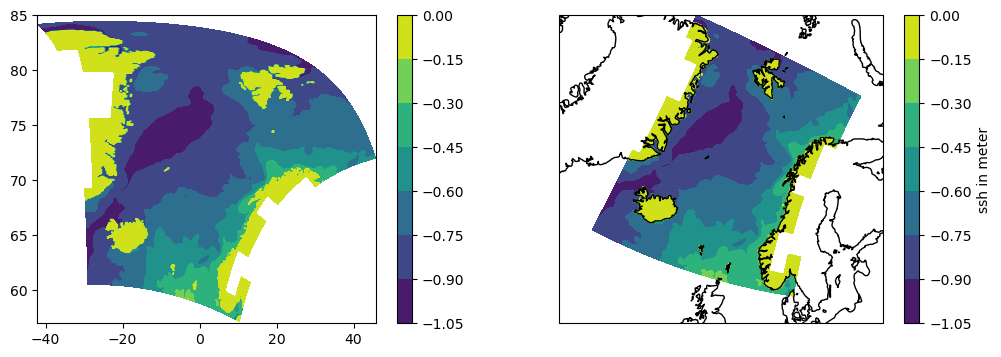

In [52]:
# Visualize a sample:
t_idx = 500

fig = plt.figure(figsize=(12, 4))

# plot in regular contour plot — no projection
ax1 = fig.add_subplot(1, 2, 1)
p1 = ax1.contourf(lon, lat, ssh[t_idx])
plt.ylim([57, 85])
plt.colorbar(p1, ax=ax1)

# plot with cartopy projection (need to install cartopy)
# visuallize ssh in NorthPolarStereo (a circular map centered on the North Pole) coordinat reference system (CRS)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.NorthPolarStereo())
p2 = ax2.contourf(lon, lat, ssh[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]
plt.colorbar(p2, ax=ax2, label='ssh in meter')

plt.show()

For training, we neeed to resample data in a coarse resolution, as using highresolution (HR) data is not efficient for training phase. 

Since FNO is a continous operator, we can later inferencce and evaluate the model on HR data.

For now, it would be good to prepocessed dataset and save them in a coarse resolution to manage our storage and resources.

You can play with the following code cells to see what is the best choice for saving data. For example, I think the grid_size of 46x46 would be good for capturing dynamics and for efficient training.

We need all variables (in original HR grids) interpolate to the grid of SSH. Then slicing to a coarse resolution.

Note:
- the size of the domain should not change. If we change the size of domain, the relation between frequencies will collapse. I suggest selecting a square domain (trim extral data along the latitude).
- convert variabls to tensor float32 before saving.
- Tensor shape is determined based on the FNO architecture. If we are supposed to use FNOtD (my suggestion), tensors should be saved with dims of (C, T, H, W), where C includs ssh, ubar, and vbar for ocean state and slp, u_wind and v_wind for atmospheric parameters. And we can have one more file for static variables like bathymetry, land_mask, reference lat and lon, etc.
- For ocean parameters, use land_mask to set zero values where we have land.
- To generalize FNO over the domain, it's the best practice to randomly slide the coarse sampling over the HR data, instead of using fixed data points. (See below)

 shape of the original grid: torch.Size([280, 230])
 - shape of coarse grid: torch.Size([46, 46])
 - domain_size: ca. 2475 km, with resolution ca. 55km


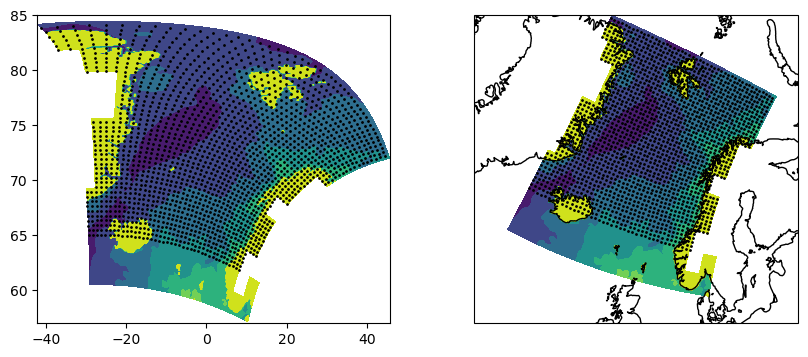

In [ ]:
# This is for test. we can play with slicing to fix a good resolutiona and domain_saize for 
# training based on the resorces we have. Note that if you fixed a domain_size for training, we 
# cannot change it in evaluation.
print(f' shape of the original grid: {lat.shape}')

res_org = 11 # approximatly
x_step = 5
lat_trim = 50
lon_trim = 0
lat_slice = slice(lat_trim, None, x_step) # by the start and end, we can fix domain_size
lon_slice = slice(lon_trim, None, x_step)

fig = plt.figure(figsize=(10, 4))

# plot regular — no projection
ax1 = fig.add_subplot(1, 2, 1)
ax1.contourf(lon, lat, ssh[t_idx])
ax1.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2)
plt.ylim([57, 85])

print(f' - shape of coarse grid: {lon[lat_slice, lon_slice].shape}')
print(f' - domain_size: ca. {(lon[lat_slice, lon_slice].shape[0]-1)*x_step*res_org} km, with resolution ca. {x_step*res_org}km')

# plot with cartopy projection (need to install cartopy)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.NorthPolarStereo())
ax2.contourf(lon, lat, ssh[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
ax2.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2, transform=ccrs.PlateCarree())
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]


i: 6, j: 3, shape: torch.Size([46, 46])


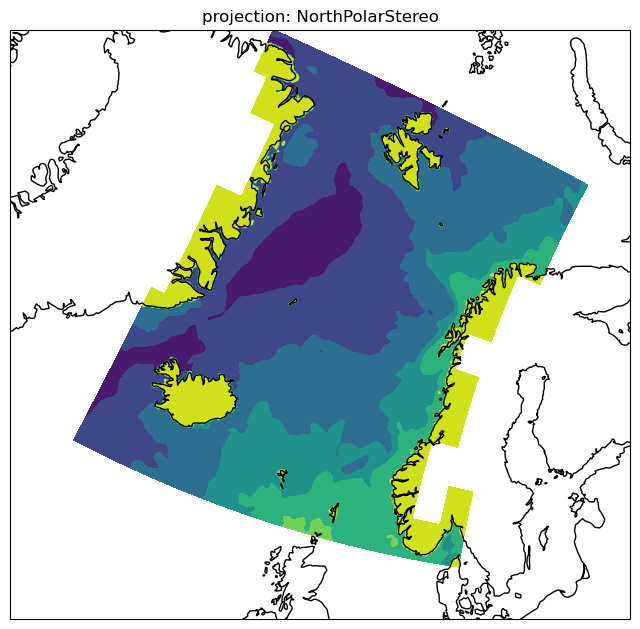

In [53]:
# This is an example to select coarse grids randomly (sliding coarse grids on HR data). 

from random import randint

t_idx = 500

n0 = 230 # data grid_size
lat_trim = 50
lon_trim = 0
x_step = 5

n = lon[:, lon_trim::x_step].shape[1] # target grid_size from above
rnd_lim = n0 - (n - 1)*x_step

i = randint(0, lat_trim + rnd_lim - 1)
j = randint(0, lon_trim + rnd_lim - 1)
lat_slice = slice(i, (-(lat_trim + rnd_lim - 1) + i) or None, x_step) #slice(35, -15, x_step)
lon_slice = slice(j, (-(lon_trim + rnd_lim - 1) + j) or None, x_step)

print(f'i: {i}, j: {j}, shape: {lon[lat_slice, lon_slice].shape}')

fig = plt.figure(figsize=[8,8])
ax2 = fig.add_subplot(projection=ccrs.NorthPolarStereo())
ax2.contourf(lon, lat, ssh[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
#ax2.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2, transform=ccrs.PlateCarree())
ax2.set_title('projection: NorthPolarStereo')
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]

In [12]:
ssh_coarse = ds_ssh.isel(time_counter=t_idx, y=lat_slice, x=lon_slice)

ssh_coarse.to_netcdf("coarse_grid_sample.nc")

C:\Users\esthe\AppData\Local\Temp\ipykernel_31212\298186022.py:3: UserWarning: Unlimited dimension(s) {'time_counter'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time_counter'} from 'dataset.encoding'.
  ssh_coarse.to_netcdf("coarse_grid_sample.nc")


In [ ]:
import numpy as np
ssh_np = ssh.detach().cpu().numpy() # convert from tensor to numpy
lat_np = lat.detach().cpu().numpy()
lon_np = lon.detach().cpu().numpy()

n0 = 230
lat_trim = 50
lon_trim = 0
x_step = 5

n = lon[:, lon_trim::x_step].shape[1]
rnd_lim = n0 - (n - 1) * x_step

ssh_samples = []
lat_samples = []
lon_samples = []
i_offsets = []
j_offsets = []

n_time = 100

for t_idx in range(n_time):
    i = randint(0, lat_trim + rnd_lim - 1)
    j = randint(0, lon_trim + rnd_lim - 1)

    lat_slice = slice(i, (-(lat_trim + rnd_lim - 1) + i) or None, x_step)
    lon_slice = slice(j, (-(lon_trim + rnd_lim - 1) + j) or None, x_step)

    ssh_samples.append(ssh_np[t_idx][lat_slice, lon_slice])
    lat_samples.append(lat[lat_slice, lon_slice])
    lon_samples.append(lon[lat_slice, lon_slice])

    i_offsets.append(i)
    j_offsets.append(j)
    ssh_coarse = ds_ssh.isel(time_counter=t_idx, y=lat_slice, x=lon_slice)

ssh_samples = np.stack(ssh_samples, axis=0)
lat_samples = np.stack(lat_samples, axis=0)
lon_samples = np.stack(lon_samples, axis=0)

#ssh_coarse.to_netcdf("coarse_grid_sample.nc")



ds_out = xr.Dataset(
    data_vars={
        "ssh": (("time", "y", "x"), ssh_samples),
        "lat": (("time", "y", "x"), lat_samples),
        "lon": (("time", "y", "x"), lon_samples),
        "i_offset": (("time",), i_offsets),
        "j_offset": (("time",), j_offsets),
    },
    coords={
        "time": np.arange(n_time),
        "y": np.arange(ssh_samples.shape[1]),
        "x": np.arange(ssh_samples.shape[2]),
    },
    attrs={
        "n0": n0,
        "lat_trim": lat_trim,
        "lon_trim": lon_trim,
        "x_step": x_step,
        "description": "Random coarse-grid SSH samples from high-resolution data",
    },
)

ds_out.to_netcdf("../data/coarse_grid_all_times.nc")

In [45]:
file = "../data//coarse_grid_sample.nc"

ds_ssh = xr.open_dataset(file, engine="netcdf4")
ds_ssh

<xarray.Dataset> Size: 25kB
Dimensions:               (axis_nbounds: 2, y: 46, x: 46)
Coordinates:
    nav_lat               (y, x) float32 8kB ...
    nav_lon               (y, x) float32 8kB ...
    time_centered         datetime64[ns] 8B ...
    time_counter          datetime64[ns] 8B ...
Dimensions without coordinates: axis_nbounds, y, x
Data variables:
    time_centered_bounds  (axis_nbounds) datetime64[ns] 16B ...
    time_counter_bounds   (axis_nbounds) datetime64[ns] 16B ...
    ssh                   (y, x) float32 8kB ...
Attributes:
    name:         NAA10KM_1h_19800101_19801231_ssh
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2026-Mar-09 19:50:28 GMT
    uuid:         570bc69b-c0fc-4aa8-aa7a-be489da1921e

In [42]:
t = ds_ssh['time_centered'].values.astype('datetime64[m]')
lat = torch.tensor(ds_ssh['nav_lat'].values, dtype=torch.float)
lon = torch.tensor(ds_ssh['nav_lon'].values, dtype=torch.float)
ssh = torch.tensor(ds_ssh['ssh'][:1000].values, dtype=torch.float)
print(ssh)

tensor([[-0.8920, -0.8661, -0.8308,  ..., -0.4408, -0.4458, -0.4158],
        [-0.9037, -0.8792, -0.8612,  ...,  0.0000, -0.4350,  0.0000],
        [-0.9090, -0.8888, -0.8784,  ...,  0.0000, -0.3881,  0.0000],
        ...,
        [    nan,     nan,  0.0000,  ..., -0.4718, -0.4350, -0.4458],
        [    nan,     nan,  0.0000,  ..., -0.5233, -0.4720, -0.4683],
        [    nan,     nan,  0.0000,  ..., -0.5849, -0.5570, -0.5283]])


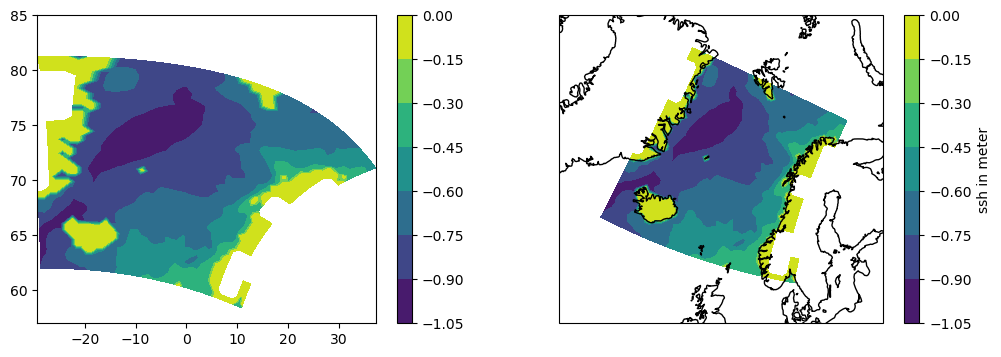

In [44]:
# Visualize a sample:
t_idx = 500

fig = plt.figure(figsize=(12, 4))

# plot in regular contour plot — no projection
ax1 = fig.add_subplot(1, 2, 1)
p1 = ax1.contourf(lon, lat, ssh)
plt.ylim([57, 85])
plt.colorbar(p1, ax=ax1)

# plot with cartopy projection (need to install cartopy)
# visuallize ssh in NorthPolarStereo (a circular map centered on the North Pole) coordinat reference system (CRS)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.NorthPolarStereo())
p2 = ax2.contourf(lon, lat, ssh, cmap='viridis', transform=ccrs.PlateCarree())
ax2.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2, transform=ccrs.PlateCarree())
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]
plt.colorbar(p2, ax=ax2, label='ssh in meter')

plt.show()

In [55]:
file = "../data//NAA10KM_1h_19800101_19801231_ubar.nc"

ds_ubar = xr.open_dataset(file, engine="netcdf4")

In [56]:
t = ds_ubar['time_centered'].values.astype('datetime64[m]')
lat = torch.tensor(ds_ubar['nav_lat'].values, dtype=torch.float)
lon = torch.tensor(ds_ubar['nav_lon'].values, dtype=torch.float)
ubar = torch.tensor(ds_ubar['ubar'][:1000].values, dtype=torch.float)
print(lat)

tensor([[60.4966, 60.4984, 60.5002,  ..., 57.1872, 57.1610, 57.1347],
        [60.5890, 60.5909, 60.5927,  ..., 57.2627, 57.2364, 57.2100],
        [60.6814, 60.6833, 60.6851,  ..., 57.3381, 57.3116, 57.2851],
        ...,
        [84.0229, 84.0471, 84.0702,  ..., 72.0587, 71.9879, 71.9171],
        [84.1037, 84.1283, 84.1517,  ..., 72.0797, 72.0087, 71.9378],
        [84.1844, 84.2093, 84.2331,  ..., 72.1002, 72.0291, 71.9581]])


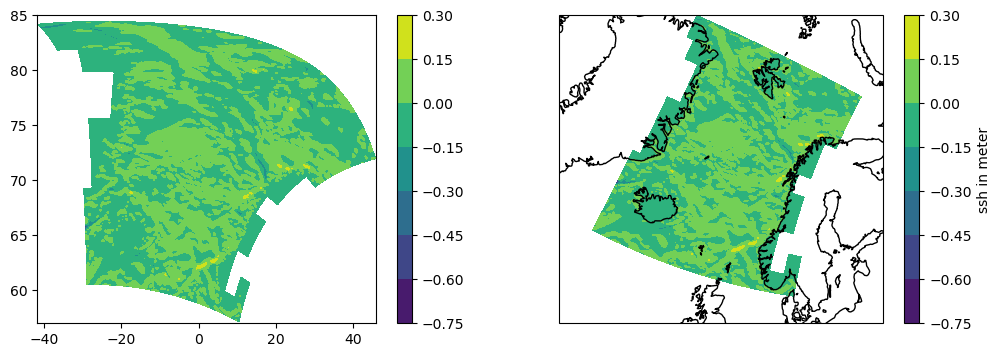

In [57]:
# Visualize a sample:
t_idx = 500

fig = plt.figure(figsize=(12, 4))

# plot in regular contour plot — no projection
ax1 = fig.add_subplot(1, 2, 1)
p1 = ax1.contourf(lon, lat, ubar[t_idx], cmap="viridis")
plt.ylim([57, 85])
plt.colorbar(p1, ax=ax1)

# plot with cartopy projection (need to install cartopy)
# visuallize ssh in NorthPolarStereo (a circular map centered on the North Pole) coordinat reference system (CRS)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.NorthPolarStereo())
p2 = ax2.contourf(lon, lat, ubar[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]
plt.colorbar(p2, ax=ax2, label='ssh in meter')

plt.show()

 shape of the original grid: torch.Size([280, 230])
 - shape of coarse grid: torch.Size([46, 46])
 - domain_size: ca. 2475 km, with resolution ca. 55km


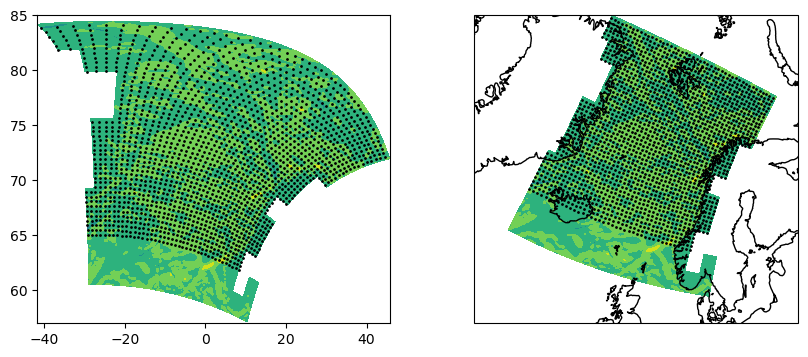

In [58]:
# This is for test. we can play with slicing to fix a good resolutiona and domain_saize for 
# training based on the resorces we have. Note that if you fixed a domain_size for training, we 
# cannot change it in evaluation.
print(f' shape of the original grid: {lat.shape}')

res_org = 11 # approximatly
x_step = 5
lat_trim = 50
lon_trim = 0
lat_slice = slice(lat_trim, None, x_step) # by the start and end, we can fix domain_size
lon_slice = slice(lon_trim, None, x_step)

fig = plt.figure(figsize=(10, 4))

# plot regular — no projection
ax1 = fig.add_subplot(1, 2, 1)
ax1.contourf(lon, lat, ubar[t_idx])
ax1.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2)
plt.ylim([57, 85])

print(f' - shape of coarse grid: {lon[lat_slice, lon_slice].shape}')
print(f' - domain_size: ca. {(lon[lat_slice, lon_slice].shape[0]-1)*x_step*res_org} km, with resolution ca. {x_step*res_org}km')

# plot with cartopy projection (need to install cartopy)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.NorthPolarStereo())
ax2.contourf(lon, lat, ubar[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
ax2.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2, transform=ccrs.PlateCarree())
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]


i: 33, j: 0, shape: torch.Size([46, 46])


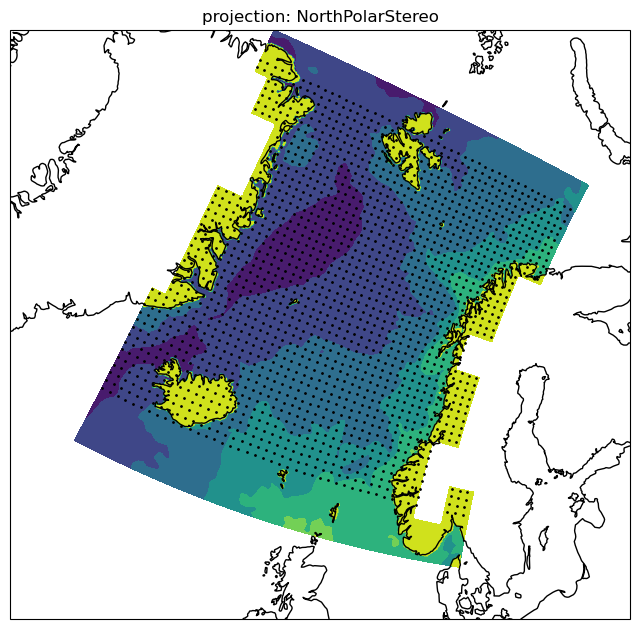

In [59]:
# This is an example to select coarse grids randomly (sliding coarse grids on HR data). 

from random import randint

t_idx = 500

n0 = 230 # data grid_size
lat_trim = 50
lon_trim = 0
x_step = 5

n = lon[:, lon_trim::x_step].shape[1] # target grid_size from above
rnd_lim = n0 - (n - 1)*x_step

i = randint(0, lat_trim + rnd_lim - 1)
j = randint(0, lon_trim + rnd_lim - 1)
lat_slice = slice(i, (-(lat_trim + rnd_lim - 1) + i) or None, x_step) #slice(35, -15, x_step)
lon_slice = slice(j, (-(lon_trim + rnd_lim - 1) + j) or None, x_step)

print(f'i: {i}, j: {j}, shape: {lon[lat_slice, lon_slice].shape}')

fig = plt.figure(figsize=[8,8])
ax2 = fig.add_subplot(projection=ccrs.NorthPolarStereo())
ax2.contourf(lon, lat, ssh[t_idx], cmap='viridis', transform=ccrs.PlateCarree())
ax2.plot(lon[lat_slice, lon_slice], lat[lat_slice, lon_slice], 'k.', markersize=2, transform=ccrs.PlateCarree())
ax2.set_title('projection: NorthPolarStereo')
ax2.coastlines() # type: ignore[attr-defined]
ax2.set_extent([-30, 25, 55, 85], crs=ccrs.PlateCarree()) # type: ignore[attr-defined]

#### nordic_seas_domain_cfg.nc file

In [60]:
domian_file = "../data/nordic_seas_domain_cfg.nc"
ds = xr.open_dataset(domian_file, engine="netcdf4")
ds.coords, ds.data_vars

(Coordinates:
     nav_lat  (y, x) float32 258kB ...
     nav_lon  (y, x) float32 258kB ...,
 Data variables:
     area                   (y, x) float64 515kB ...
     bathy_metry            (y, x) float32 258kB ...
     bottom_level           (y, x) int32 258kB ...
     e1f                    (y, x) float64 515kB ...
     e1t                    (y, x) float64 515kB ...
     e1u                    (y, x) float64 515kB ...
     e1v                    (y, x) float64 515kB ...
     e2f                    (y, x) float64 515kB ...
     e2t                    (y, x) float64 515kB ...
     e2u                    (y, x) float64 515kB ...
     e2v                    (y, x) float64 515kB ...
     e3f_0                  (z, y, x) float64 39MB ...
     e3t_0                  (z, y, x) float64 39MB ...
     e3t_1d                 (z) float64 600B ...
     e3u_0                  (z, y, x) float64 39MB ...
     e3uw_0                 (z, y, x) float64 39MB ...
     e3v_0                  (z, y, x) fl

In [61]:
lat_2 = torch.tensor(ds['nav_lat'].values, dtype=torch.float)
lon_2 = torch.tensor(ds['nav_lon'].values, dtype=torch.float)

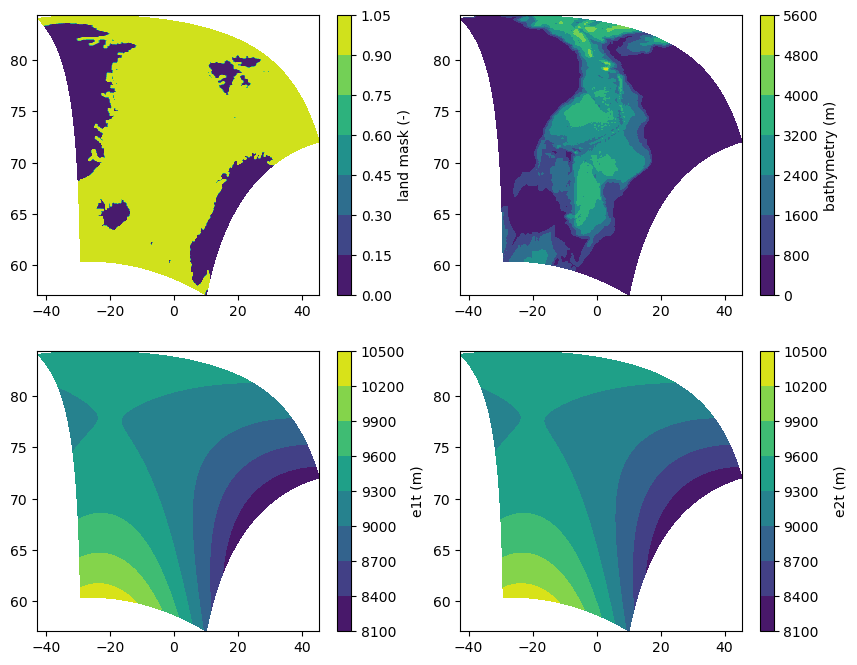

In [62]:
# land mask: land is zero, ocean 1
land_mask = torch.tensor(ds['top_level'].values, dtype=torch.float)

# bathymetry:
bth = torch.tensor(ds['bathy_metry'].values, dtype=torch.float)

# cell scale factors for ssh grids in the east-west (e1t) and south-north (e2t) directions. They are distance between grid points over the doamin
e1t = torch.tensor(ds['e1t'].values, dtype=torch.float)
e2t = torch.tensor(ds['e2t'].values, dtype=torch.float)


plt.figure(figsize=[10,8])
plt.subplot(221)
plt.contourf(lon_2, lat_2, land_mask)
plt.colorbar(label='land mask (-)')

plt.subplot(222)
plt.contourf(lon_2, lat_2, bth)
plt.colorbar(label='bathymetry (m)')

plt.subplot(223)
plt.contourf(lon_2, lat_2, e1t)
plt.colorbar(label= 'e1t (m)')

plt.subplot(224)
plt.contourf(lon_2, lat_2, e2t)
plt.colorbar(label= 'e2t (m)')
plt.show()